<a href="https://colab.research.google.com/github/ilincabaiasu/IB9AU/blob/main/Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Required Task 1

### Details

**Topic**: Natural Language Processing

**Sub-topic**: Topic_Modeling_Illustration (Topic_Modeling_Illustration.ipynb)


---


**Instructions**:

Your tasks involves the fakenews.csv file.
1. Compute the sentiment of text. Is the sentiment for spam messages higher or lower than normal messages?
2. Conduct topic modelling on ‘text’. How many topics are appropriate? How are these topics related to spam/not spam?


---

**What I found interesting:**
- Spam and potentially fake news can be identified through sentiment analysis
- Spam messages and fake news have compositional patterns, distinguishable from regular news
- Surprising results: positive sensiment polarity is associated with spam messages

### Imports

In [37]:
!pip install gensim pyLDAvis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sentiment
from textblob import TextBlob

# Text preprocessing
import re
import string
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Topic modelling
from gensim import corpora, models
from gensim.models import CoherenceModel

# LDA visualisation
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Suppress minor warnings
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### Load data

In [38]:
df = pd.read_csv('fakenews.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
df.head()

Shape: (4912, 427)
Columns: ['text', 'label', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59', 'Unnamed: 60', 'Unnamed: 61', 'Unnamed: 62', 'Unnamed: 63', 'Unnamed: 64', 'Unnamed: 65', 'U

,text,label,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 417,Unnamed: 418,Unnamed: 419,Unnamed: 420,Unnamed: 421,Unnamed: 422,Unnamed: 423,Unnamed: 424,Unnamed: 425,Unnamed: 426
0,Get the latest from TODAY Sign up for our news...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2d Conan On The Funeral Trump Will Be Invited...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,It’s safe to say that Instagram Stories has fa...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Much like a certain Amazon goddess with a lass...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,At a time when the perfect outfit is just one ...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
print(f"Initial DataFrame shape: {df.shape}")

# Identify 'Unnamed: X' columns that are almost entirely empty
unnamed_cols = [col for col in df.columns if 'Unnamed:' in col]
empty_unnamed_cols = [col for col in unnamed_cols if df[col].isnull().all()]

# Drop these empty 'Unnamed' columns
if empty_unnamed_cols:
    df.drop(columns=empty_unnamed_cols, inplace=True)
    print(f"Dropped {len(empty_unnamed_cols)} empty 'Unnamed' columns.")
else:
    print("No entirely empty 'Unnamed' columns to drop.")

print(f"DataFrame shape after dropping empty 'Unnamed' columns: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")
display(df.head())

Initial DataFrame shape: (4912, 427)
No entirely empty 'Unnamed' columns to drop.
DataFrame shape after dropping empty 'Unnamed' columns: (4912, 427)
Remaining columns: ['text', 'label', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 5

,text,label,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 417,Unnamed: 418,Unnamed: 419,Unnamed: 420,Unnamed: 421,Unnamed: 422,Unnamed: 423,Unnamed: 424,Unnamed: 425,Unnamed: 426
0,Get the latest from TODAY Sign up for our news...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2d Conan On The Funeral Trump Will Be Invited...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,It’s safe to say that Instagram Stories has fa...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Much like a certain Amazon goddess with a lass...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,At a time when the perfect outfit is just one ...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
# Drop rows with missing text
df.dropna(subset=['text'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Rows after dropping missing text: {len(df)}")

Rows after dropping missing text: 4912


### Sub-task 1: Sentiment Analysis

In [41]:
# Compute polarity for every message
df['polarity'] = df['text'].apply(lambda t: TextBlob(str(t)).sentiment.polarity)

# Quick look at the results
print("Sample polarity scores:")
df[['text', 'label', 'polarity']].head(10)

Sample polarity scores:


,text,label,polarity
0,Get the latest from TODAY Sign up for our news...,1,0.189989
1,2d Conan On The Funeral Trump Will Be Invited...,1,0.000000
2,It’s safe to say that Instagram Stories has fa...,0,0.230229
3,Much like a certain Amazon goddess with a lass...,0,0.133501
4,At a time when the perfect outfit is just one ...,0,0.107985
5,"When Reese Witherspoon was 17, she had already...",0,0.131063
6,It’s official! WAGS Miami stars Ashley Nicole ...,0,0.265179
7,"On March 24, 2018, one month and ten days afte...",1,0.094823
8,A mosque in Georgia is under fire after they s...,1,0.258333
9,Scott Disick is sticking up for Khloe Kardashi...,1,0.117494


In [42]:
# Descriptive statistics grouped by label
sentiment_summary = df.groupby('label')['polarity'].agg(['mean', 'median', 'std', 'count'])
sentiment_summary.columns = ['Mean Polarity', 'Median Polarity', 'Std Dev', 'Count']
print("Sentiment Summary by Label:")
sentiment_summary

Sentiment Summary by Label:


,Mean Polarity,Median Polarity,Std Dev,Count
label,,,,
0,0.147766,0.137514,0.123606,1733
1,0.118603,0.109766,0.113295,1131
And Always Will Be,0.386667,0.386667,NaN,1
Ms Guerrero said she brought a female casting director with her. She said Mr Seagal answered the door in a silk robe and although he never exposed himself to her or touched her,-0.050000,-0.050000,NaN,1
a child advocacy and research group.[166] In 2006,0.000000,0.000000,NaN,1
she has said.[188] Although stopping short of an endorsement,0.000000,0.000000,NaN,1
so they felt she should be the one moved off the pole,0.000000,0.000000,NaN,1
the lieutenant finally notices that their orders were never officially signed by the master-at-arms in Norfolk,0.000000,0.000000,NaN,1
0,0.150405,0.142085,0.135032,1192


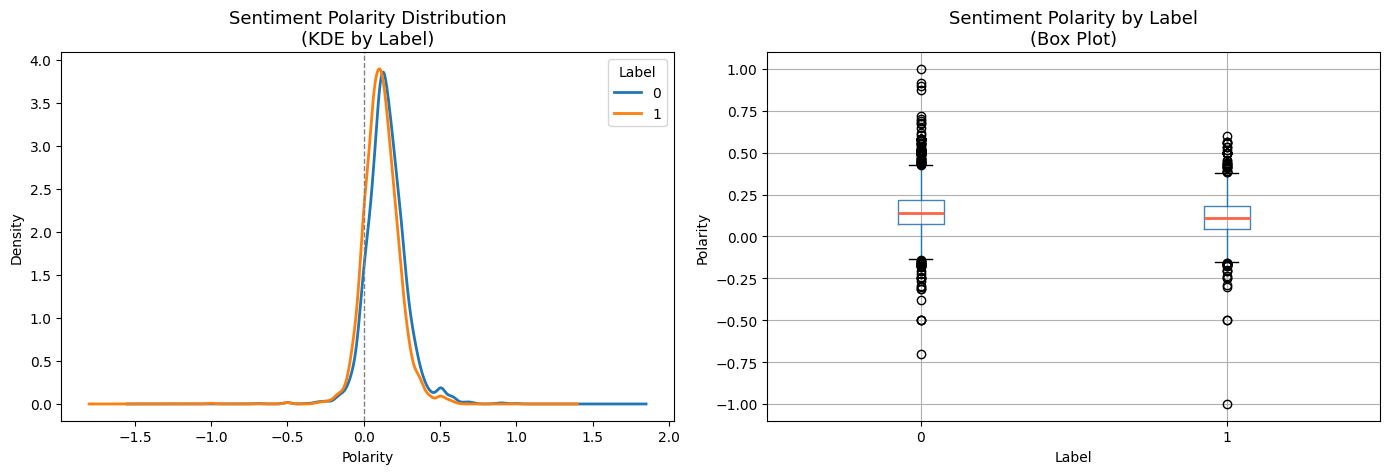

In [43]:
# Visualise sentiment distributions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Data Cleaning for 'label' column ---
# Create a cleaned copy of the DataFrame for plotting
df_cleaned = df.copy()
# Convert 'label' column to numeric, coercing any errors (non-numeric values) to NaN
df_cleaned['label'] = pd.to_numeric(df_cleaned['label'], errors='coerce')
# Drop rows where 'label' is NaN (i.e., was not a valid number like 0 or 1)
df_cleaned.dropna(subset=['label'], inplace=True)
# Convert cleaned 'label' to integer type
df_cleaned['label'] = df_cleaned['label'].astype(int)

# ── Left: overlapping KDE curves ──────────────────────────────────────────────
# Iterate over the cleaned DataFrame groups
for label, grp in df_cleaned.groupby('label'):
    # Only attempt to plot KDE if the group has more than one data point
    if len(grp['polarity']) > 1:
        grp['polarity'].plot.kde(ax=axes[0], label=str(label), linewidth=2)
    else:
        print(f"Skipping KDE plot for label {label} as it has only one data point.")

axes[0].axvline(0, color='grey', linestyle='--', linewidth=1)
axes[0].set_title('Sentiment Polarity Distribution\n(KDE by Label)', fontsize=13)
axes[0].set_xlabel('Polarity')
axes[0].set_ylabel('Density')
axes[0].legend(title='Label')

# ── Right: boxplot ─────────────────────────────────────────────────────────────
# Use the cleaned DataFrame for the boxplot as well
df_cleaned.boxplot(column='polarity', by='label', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='tomato', linewidth=2))
axes[1].set_title('Sentiment Polarity by Label\n(Box Plot)', fontsize=13)
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Polarity')
plt.suptitle('')   # Remove the default pandas suptitle

plt.tight_layout()
plt.show()

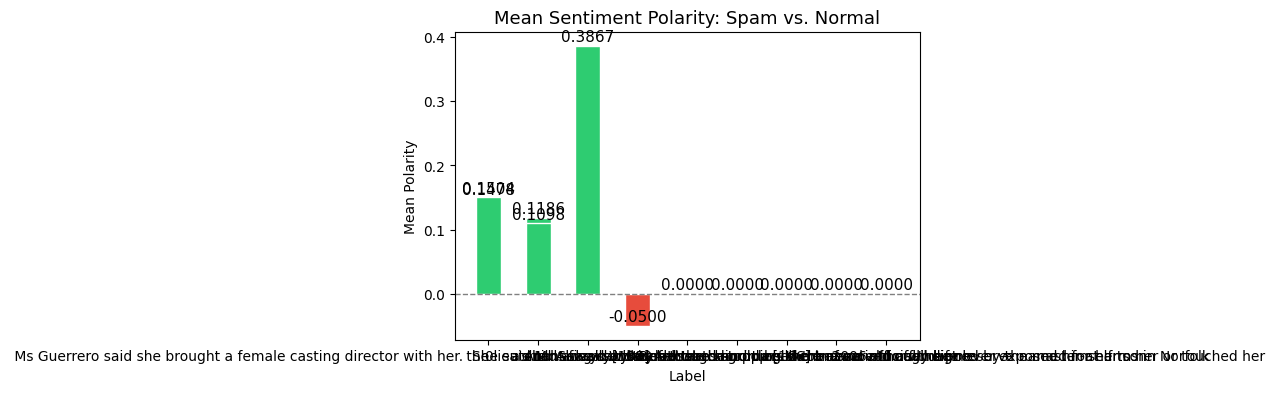

In [44]:
# Bar chart of mean polarity — makes the directional difference immediately clear
means = df.groupby('label')['polarity'].mean()
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in means]

plt.figure(figsize=(6, 4))
bars = plt.bar(means.index.astype(str), means.values, color=colors, edgecolor='white', width=0.5)
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.title('Mean Sentiment Polarity: Spam vs. Normal', fontsize=13)
plt.xlabel('Label')
plt.ylabel('Mean Polarity')
for bar, val in zip(bars, means.values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

In [45]:
# Statistical test
# We use a **Mann-Whitney U test** (non-parametric, appropriate for non-normal polarity distributions) to determine
# whether the difference in sentiment between groups is statistically significant.

from scipy import stats

# --- Data Cleaning for 'label' column ---
# Create a cleaned copy of the DataFrame for this operation to avoid modifying the original df directly unless intended
df_cleaned_for_stats = df.copy()
# Convert 'label' column to numeric, coercing any errors (non-numeric values) to NaN
df_cleaned_for_stats['label'] = pd.to_numeric(df_cleaned_for_stats['label'], errors='coerce')
# Drop rows where 'label' is NaN (i.e., was not a valid number like 0 or 1)
df_cleaned_for_stats.dropna(subset=['label'], inplace=True)
# Convert cleaned 'label' to integer type
df_cleaned_for_stats['label'] = df_cleaned_for_stats['label'].astype(int)

# Separate polarity scores by label using the cleaned DataFrame
labels = df_cleaned_for_stats['label'].unique()

# Ensure there are at least two distinct labels (0 and 1) for comparison
if len(labels) < 2:
    print("Error: Not enough distinct numerical labels (0 and 1) to perform statistical test after cleaning.")
else:
    # Assuming the relevant labels are 0 and 1, we can explicitly get them
    # If other numerical labels exist, this might need adjustment based on context
    if 0 in labels and 1 in labels:
        label_a = 0
        label_b = 1
    else:
        # If not exactly 0 and 1, take the first two available unique numerical labels
        labels_sorted = sorted(labels)
        label_a, label_b = labels_sorted[0], labels_sorted[1]

    group_a = df_cleaned_for_stats.loc[df_cleaned_for_stats['label'] == label_a, 'polarity'].values
    group_b = df_cleaned_for_stats.loc[df_cleaned_for_stats['label'] == label_b, 'polarity'].values

    # Ensure both groups have enough data points for the test
    if len(group_a) > 0 and len(group_b) > 0:
        stat, p_value = stats.mannwhitneyu(group_a, group_b, alternative='two-sided')

        print(f"Mann-Whitney U statistic : {stat:.2f}")
        print(f"p-value                  : {p_value:.4f}")
        if p_value < 0.05:
            print("→ The difference in sentiment between the two groups is statistically significant (p < 0.05).")
        else:
            print("→ No statistically significant difference detected (p ≥ 0.05).")
    else:
        print("Error: One or both groups are empty after cleaning and filtering, cannot perform statistical test.")


Mann-Whitney U statistic : 3361805.00
p-value                  : 0.0000
→ The difference in sentiment between the two groups is statistically significant (p < 0.05).


### Sub-task 2: Topic Modelling with LDA

In [46]:
# Text preprocessing

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    """Clean, tokenise, remove stopwords, and lemmatise a document."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)                 # keep only letters
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

print("Preprocessing text — this may take a moment...")
df['tokens'] = df['text'].apply(preprocess)

# Show a sample
print("\nSample original text:")
print(df['text'].iloc[0][:200])
print("\nSample tokens:")
print(df['tokens'].iloc[0][:20])

Preprocessing text — this may take a moment...

Sample original text:
Get the latest from TODAY Sign up for our newsletter  No one ever truly gets over losing a loved one, and Blake Shelton is no exception. He was just 14 when his older brother Richie died on Nov. 13, 1

Sample tokens:
['get', 'latest', 'today', 'sign', 'newsletter', 'one', 'ever', 'truly', 'get', 'losing', 'loved', 'one', 'blake', 'shelton', 'exception', 'older', 'brother', 'richie', 'died', 'nov']


In [47]:
# dictionary -> maps each token to an int id
# corpus -> converts each doc to a bag-of-words implementation


# Build the dictionary from all tokenised documents
dictionary = corpora.Dictionary(df['tokens'])

# Filter out very rare and very common words to improve topic quality
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Convert each document to a bag-of-words vector
corpus = [dictionary.doc2bow(tokens) for tokens in df['tokens']]

print(f"Dictionary size (unique tokens): {len(dictionary)}")
print(f"Corpus size (documents)        : {len(corpus)}")
print(f"\nSample BOW for document 0 (first 10 pairs):")
print(corpus[0][:10])
print("\n(Each tuple is (word_id, frequency) — identical to the Gensim format shown in the illustration notebook)")

Dictionary size (unique tokens): 15843
Corpus size (documents)        : 4912

Sample BOW for document 0 (first 10 pairs):
[(0, 2), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 6)]

(Each tuple is (word_id, frequency) — identical to the Gensim format shown in the illustration notebook)


In [ ]:
# Evaluate LDA coherence for k = 2..12
k_values = range(2, 13)
coherence_scores = []

# coherence score -> how semantically consistent the top words within each topic are

print("Training LDA models and computing coherence scores...")
for k in k_values:
    lda_model = models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10,
        alpha='auto',
        eta='auto'
    )
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=df['tokens'].tolist(),
        dictionary=dictionary,
        coherence='c_v'
    )
    score = coherence_model.get_coherence()
    coherence_scores.append(score)
    print(f"  k={k:2d}  Coherence={score:.4f}")

# Identify optimal k
optimal_k = list(k_values)[np.argmax(coherence_scores)]
print(f"\n→ Optimal number of topics (highest coherence): k = {optimal_k}")

Training LDA models and computing coherence scores...


In [ ]:
# Plot coherence scores against number of topics
plt.figure(figsize=(9, 4))
plt.plot(list(k_values), coherence_scores, marker='o', linewidth=2, color='steelblue')
plt.axvline(optimal_k, color='tomato', linestyle='--', linewidth=1.5, label=f'Optimal k = {optimal_k}')
plt.title('LDA Coherence Score vs. Number of Topics', fontsize=13)
plt.xlabel('Number of Topics (k)')
plt.ylabel('Coherence Score (c_v)')
plt.xticks(list(k_values))
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nInterpretation: The coherence score peaks at k = {optimal_k}, meaning {optimal_k} topics"
      " produce the most internally consistent and semantically meaningful topics.")

Train final FDA model

In [ ]:
# Train the final LDA model with the optimal number of topics
lda_final = models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=optimal_k,
    random_state=42,
    passes=15,
    alpha='auto',
    eta='auto'
)

# Print the top 10 words for each topic
print(f"Top words per topic (Final LDA model, k = {optimal_k}):\n")
for i, topic in lda_final.print_topics(num_words=10):
    print(f"Topic {i}: {topic}\n")

Visualise topics

In [ ]:
# Horizontal bar charts — one subplot per topic (reference notebook style)
n_words = 8
palette = sns.color_palette('tab10', optimal_k)

fig, axes = plt.subplots(
    nrows=int(np.ceil(optimal_k / 2)), ncols=2,
    figsize=(14, 3.5 * int(np.ceil(optimal_k / 2)))
)
axes = axes.flatten()

for topic_id in range(optimal_k):
    top_words = lda_final.show_topic(topic_id, topn=n_words)
    words  = [w for w, _ in top_words]
    scores = [s for _, s in top_words]

    axes[topic_id].barh(words[::-1], scores[::-1], color=palette[topic_id])
    axes[topic_id].set_title(f'Topic {topic_id}', fontsize=12)
    axes[topic_id].set_xlabel('Word Probability')

# Hide any unused subplots
for j in range(optimal_k, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top Words per LDA Topic', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Interactive pyLDAvis visualisation
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_final, corpus, dictionary, sort_topics=False)
pyLDAvis.display(vis)

In [ ]:
# Assign dominant topic to each doc

def get_dominant_topic(bow_doc):
    """Return the topic with the highest probability for a single document."""
    topic_probs = lda_final.get_document_topics(bow_doc)
    if not topic_probs:
        return -1, 0.0
    dominant = max(topic_probs, key=lambda x: x[1])
    return dominant[0], round(dominant[1], 4)

# Apply to every document in the corpus
results = [get_dominant_topic(doc) for doc in corpus]
df['dominant_topic'] = [r[0] for r in results]
df['topic_probability'] = [r[1] for r in results]

# Attach the top-3 words for each topic as a readable label
topic_labels = {
    i: ', '.join([w for w, _ in lda_final.show_topic(i, topn=3)])
    for i in range(optimal_k)
}
df['topic_label'] = df['dominant_topic'].map(topic_labels)

print("Sample of dominant topic assignments:")
df[['text', 'label', 'dominant_topic', 'topic_probability', 'topic_label']].head(10)

How do topics relate to spam vs normal?

In [ ]:
# Cross-tabulation: count of documents per (label, dominant_topic)
cross_tab = pd.crosstab(df['label'], df['dominant_topic'])
print("Document counts per label and dominant topic:")
print(cross_tab)

# Normalise by row so we see the topic distribution WITHIN each class
cross_tab_norm = cross_tab.div(cross_tab.sum(axis=1), axis=0).round(3)
print("\nNormalised (proportion within each label):")
print(cross_tab_norm)

In [ ]:
# Heatmap — proportion of each topic within spam vs. normal
plt.figure(figsize=(max(8, optimal_k), 4))
sns.heatmap(
    cross_tab_norm,
    annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Proportion'}
)
plt.title('Topic Distribution Within Each Label\n(Row-normalised Heatmap)', fontsize=13)
plt.xlabel('Dominant Topic')
plt.ylabel('Label')
plt.tight_layout()
plt.show()

In [ ]:
# Grouped bar chart — easier to spot which topics are over-represented in spam
cross_tab_norm.T.plot(
    kind='bar', figsize=(max(8, optimal_k + 2), 5),
    colormap='Set2', edgecolor='white'
)
plt.title('Topic Share by Label\n(Proportion of documents with each dominant topic)', fontsize=13)
plt.xlabel('Dominant Topic')
plt.ylabel('Proportion of Documents')
plt.xticks(rotation=0)
plt.legend(title='Label')
plt.tight_layout()
plt.show()

In [ ]:
# Spam-to-normal ratio per topic — a ratio > 1 means the topic is more
# prevalent in spam; < 1 means it is more prevalent in normal messages.

# --- Data Cleaning for 'label' column in this cell ---
df_cleaned_for_ratio = df.copy()
df_cleaned_for_ratio['label'] = pd.to_numeric(df_cleaned_for_ratio['label'], errors='coerce')
df_cleaned_for_ratio.dropna(subset=['label'], inplace=True)
df_cleaned_for_ratio['label'] = df_cleaned_for_ratio['label'].astype(int)

label_vals = sorted(df_cleaned_for_ratio['label'].unique())

# Compute proportion of each topic for the two groups
topic_props = (
    df_cleaned_for_ratio.groupby(['label', 'dominant_topic'])
    .size()
    .unstack(fill_value=0)
    .div(df_cleaned_for_ratio['label'].value_counts(), axis=0)
)

# Print for inspection
print("Proportion of each topic within each label group:")
print(topic_props.round(4))

# Calculate the ratio only if both labels (0 and 1) are present after cleaning
if 0 in label_vals and 1 in label_vals:
    # Ensure we only consider the 0 and 1 labels for the ratio
    if 0 in topic_props.index and 1 in topic_props.index:
        spam_to_normal_ratio = topic_props.loc[1] / topic_props.loc[0]
        print("\nSpam-to-Normal Ratio per Topic:")
        print(spam_to_normal_ratio.round(2))

        # Plot the ratios
        plt.figure(figsize=(max(8, optimal_k), 4))
        spam_to_normal_ratio.plot(kind='bar', color='skyblue', edgecolor='black')
        plt.axhline(1, color='red', linestyle='--', linewidth=1, label='Ratio = 1 (Equal prevalence)')
        plt.title('Spam-to-Normal Topic Prevalence Ratio', fontsize=13)
        plt.xlabel('Topic')
        plt.ylabel('Ratio (Spam Proportion / Normal Proportion)')
        plt.xticks(rotation=0)
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("\nWarning: Cannot calculate spam-to-normal ratio. One or both primary labels (0 or 1) are missing in topic proportions after cleaning.")
else:
    print("\nWarning: Cannot calculate spam-to-normal ratio. Not enough distinct numerical labels (0 and 1) after cleaning.")